In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    log_loss,
    RocCurveDisplay
)

In [4]:
# Load in our dataset
climate = datasets.fetch_openml(
    name='climate-model-simulation-crashes',
    version=1,
    parser='auto'
)

X = climate.data

# Encode target
y = LabelEncoder().fit_transform(climate.target)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Covert to pandas dataframe
climate_df = pd.DataFrame(data=X, columns=climate.feature_names)

# Show head of dataframe
print(climate_df.head())

   V1  V2   V3        V4        V5        V6        V7        V8        V9  \
0   1   1  502  0.927825  0.252866  0.298838  0.170521  0.735936  0.428325   
1   1   2  249  0.457728  0.359448  0.306957  0.843331  0.934851  0.444572   
2   1   3  202  0.373238  0.517399  0.504993  0.618903  0.605571  0.746225   
3   1   4   56  0.104055  0.197533  0.421837  0.742056  0.490828  0.005525   
4   1   5  278  0.513199  0.061812  0.635837  0.844798  0.441502  0.191926   

        V10       V11       V12       V13       V14       V15       V16  \
0  0.567947  0.474370  0.245675  0.104226  0.869091  0.997518  0.448620   
1  0.828015  0.296618  0.616870  0.975786  0.914344  0.845247  0.864152   
2  0.195928  0.815667  0.679355  0.803413  0.643995  0.718441  0.924775   
3  0.392123  0.010015  0.471463  0.597879  0.761659  0.362751  0.912819   
4  0.487546  0.358534  0.551543  0.743877  0.312349  0.650223  0.522261   

        V17       V18       V19       V20  
0  0.307522  0.858310  0.796997  0.8

In [6]:
# Show summary statistics
print(climate_df.describe())

               V1          V2          V3          V4          V5          V6  \
count  540.000000  540.000000  540.000000  540.000000  540.000000  540.000000   
mean     2.000000   90.500000  270.500000    0.500096    0.500027    0.500119   
std      0.817254   52.008901  156.028843    0.288922    0.289067    0.288993   
min      1.000000    1.000000    1.000000    0.001922    0.001181    0.001972   
25%      1.000000   45.750000  135.750000    0.251597    0.251540    0.250159   
50%      2.000000   90.500000  270.500000    0.499595    0.500104    0.500456   
75%      3.000000  135.250000  405.250000    0.750011    0.749180    0.750348   
max      3.000000  180.000000  540.000000    0.998815    0.998263    0.997673   

               V7          V8          V9         V10         V11         V12  \
count  540.000000  540.000000  540.000000  540.000000  540.000000  540.000000   
mean     0.500001    0.499913    0.500059    0.500076    0.500044    0.500111   
std      0.288827    0.2888

In [7]:
# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Model init and fitting
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [10]:
# Make predictions
y_pred = lr.predict(X_test_scaled)

# Show results
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.9074074074074074
Confusion Matrix:
 [[ 1  9]
 [ 1 97]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.10      0.17        10
           1       0.92      0.99      0.95        98

    accuracy                           0.91       108
   macro avg       0.71      0.54      0.56       108
weighted avg       0.88      0.91      0.88       108



In [11]:
# Predict confidence scores
confidence_scores = lr.decision_function(X_test_scaled)
print('Confidence Scores:\n', confidence_scores)

# Predict probabilities
probabilities = lr.predict_proba(X_test_scaled)
print('Probabilities:\n', probabilities)

Confidence Scores:
 [ 4.01631924  5.14138488  1.0384386   5.97938798  8.16789448  0.01760172
  1.74826581  1.32959871  8.74872512  5.16338346  2.19438592  1.08151271
  6.26548508  5.4457324   4.1139243   1.216596    6.76456957  1.23382068
  5.25461344  5.87718174  1.63564032  3.34809994  7.48835731  1.79284163
 -0.42323977  4.84169431  6.41906469  2.44453182  3.93527642  1.08061433
  3.56155677  0.94011636  6.31365117  2.79781856  4.75342914  6.7884057
  5.09329773  0.76191382  3.93141637  3.19794875  5.2527236   3.62960668
  3.44693123  6.73651267  2.62799212  0.5556986   2.32613155  5.68199737
  4.84528575  1.10339227  4.43486359  4.2940277   3.15023522  2.51215884
  4.0465332   3.63428215  0.10068465  2.49689878  7.13573077  2.71868824
  5.18070018  7.6001764   2.10455388  3.11915451  7.20313554  6.01583299
  2.98908178  5.34882387  3.16183417  2.87369135  5.59582556  1.53417589
  6.3497824   6.10621558  3.46606183  3.15405604 -0.31056341  3.45172139
  7.59364665  1.03134538  2.8573

In [14]:
# Compute ROC AUC score
roc_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
print('ROC AUC Score:', roc_auc)

# Compute log loss
log_loss_val = log_loss(y_test, lr.predict_proba(X_test_scaled))
print('Log Loss:', log_loss_val)

ROC AUC Score: 0.8724489795918368
Log Loss: 0.22518791737006225


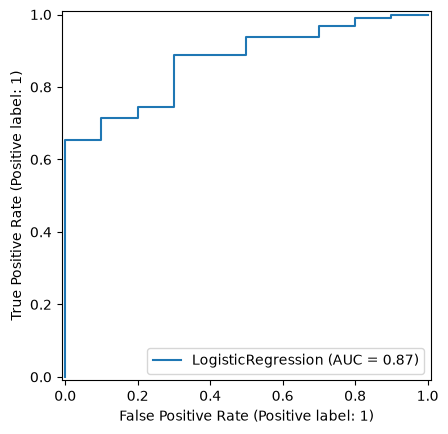

In [15]:
# Plot ROC curve
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.show()

In [16]:
# Cross-validation (K-fold, K = 5) time
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

Cross-Validation Scores: [0.91954023 0.87356322 0.89534884 0.94186047 0.91860465]
Mean CV Score: 0.9097834803528467


In [19]:
# Setup model with L2 regularization
l2_lr = LogisticRegression(l1_ratio=0, solver='saga', max_iter=10000, random_state=42)
l2_lr.fit(X_train_scaled, y_train)

# Setup model with L1 regularization
l1_lr = LogisticRegression(l1_ratio=1, solver='saga', max_iter=10000, random_state=42)
l1_lr.fit(X_train_scaled, y_train)

,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 an

In [20]:
# Make predictions on test set
l2_pred = l2_lr.predict(X_test_scaled)
l1_pred = l1_lr.predict(X_test_scaled)

# Evaluate both L1 and L2 models
print('Classification Report L2:\n', classification_report(y_test, l2_pred))
print('Classification Report L1:\n', classification_report(y_test, l1_pred))

Classification Report L2:
               precision    recall  f1-score   support

           0       0.50      0.10      0.17        10
           1       0.92      0.99      0.95        98

    accuracy                           0.91       108
   macro avg       0.71      0.54      0.56       108
weighted avg       0.88      0.91      0.88       108

Classification Report L1:
               precision    recall  f1-score   support

           0       0.67      0.20      0.31        10
           1       0.92      0.99      0.96        98

    accuracy                           0.92       108
   macro avg       0.80      0.59      0.63       108
weighted avg       0.90      0.92      0.90       108



In [23]:
# Balance class weights
cw_lr = LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42)
cw_lr.fit(X_train_scaled, y_train)

# Compute accuracy
cw_pred = cw_lr.predict(X_test_scaled)
print('Balanced Class Weight Classification Report:', classification_report(y_test, cw_pred))

Balanced Class Weight Classification Report:               precision    recall  f1-score   support

           0       0.23      0.70      0.35        10
           1       0.96      0.77      0.85        98

    accuracy                           0.76       108
   macro avg       0.60      0.73      0.60       108
weighted avg       0.89      0.76      0.81       108

